<a href="https://colab.research.google.com/github/Thienluong9999/IoT_ph-ng_kh-m_th-_y/blob/main/MLTrain_Notebook/Notebook/ML/MLEsp32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MQ2_pct_change    0
MQ3_pct_change    0
MQ4_pct_change    0
dtype: int64

========== Cluster Center ==========

L0 | centroid = -4.858% | samples = 5622
L1 | centroid = -0.011% | samples = 68919
L2 | centroid = 6.822% | samples = 2891
L3 | centroid = 18.504% | samples = 783

========== Pollution Level ==========

pollution_level
0     5622
1    68919
2     2891
3      783
Name: count, dtype: int64

========== Feature Engineering Data ==========

Số lượng features đầu vào: 22 (bao gồm Hour_sin/cos)
Target dự báo: target_t5

    MQ2_pct_change_lag0_zscore  MQ2_pct_change_lag1_zscore  Hour_sin  \
21                   -1.096452                   -1.261797 -0.965926   
22                   -0.960298                   -1.096452 -0.965926   
23                   -0.844619                   -0.960298 -0.965926   
24                   -0.744036                   -0.844619 -0.965926   
25                   -1.117014                   -0.744036 -0.965926   

    target_t5  
21  -0.398406  
22  -0

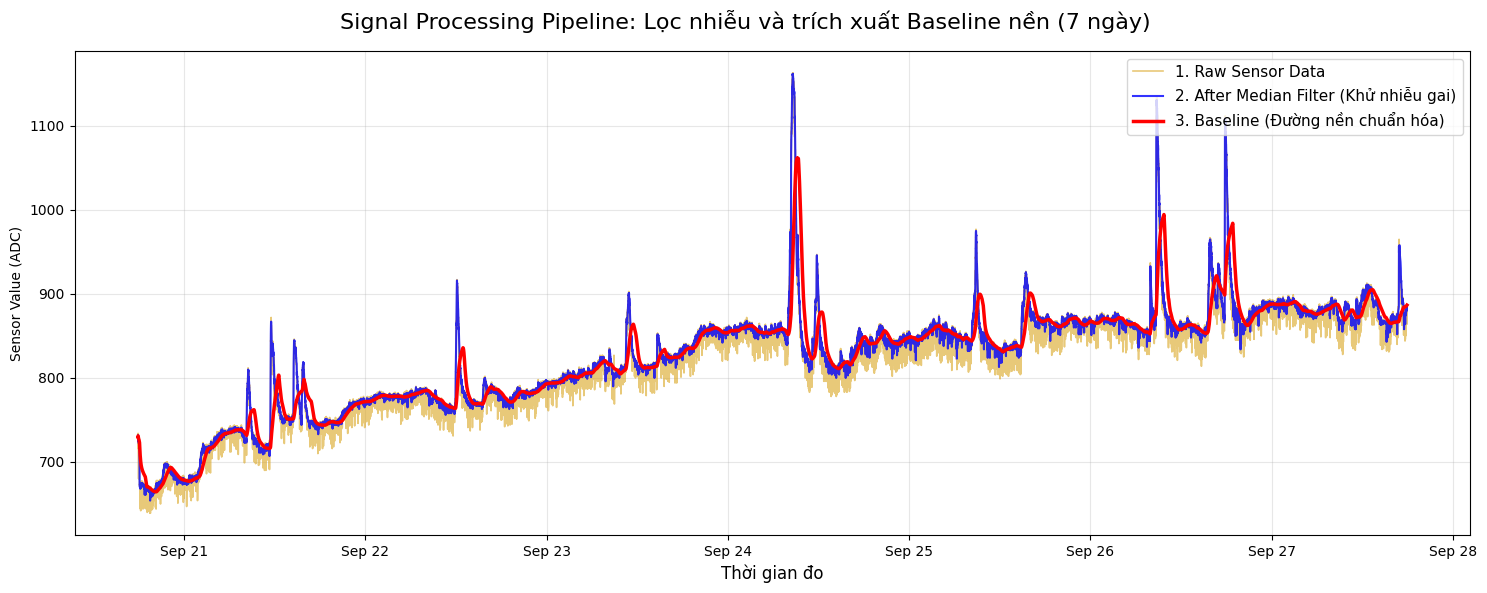

Bỏ qua biểu đồ 2: Bạn chưa uncomment đoạn code tính Elbow & Silhouette phía trên.


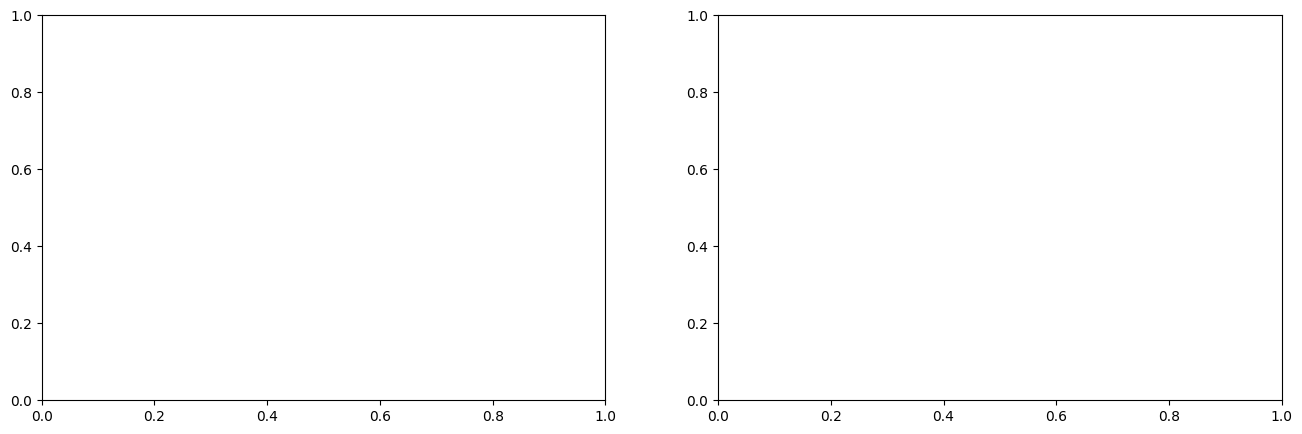

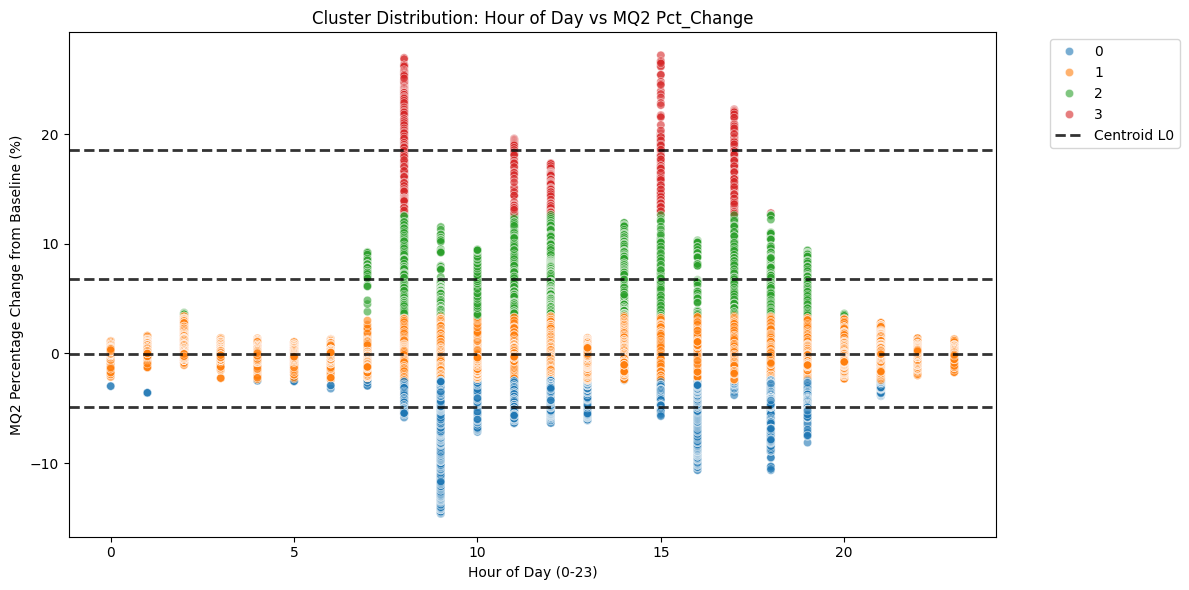

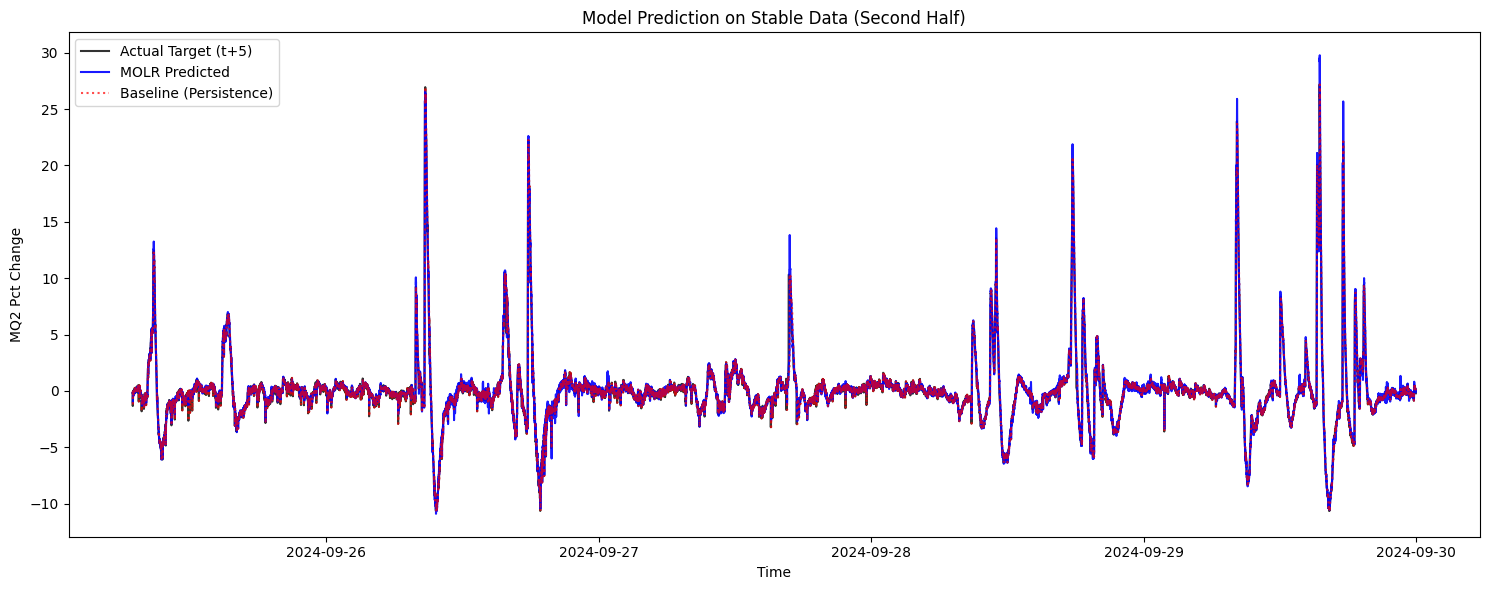

/tmp/ipykernel_1012/3739070432.py:769: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='feature', data=df_weights_sorted, palette=colors)


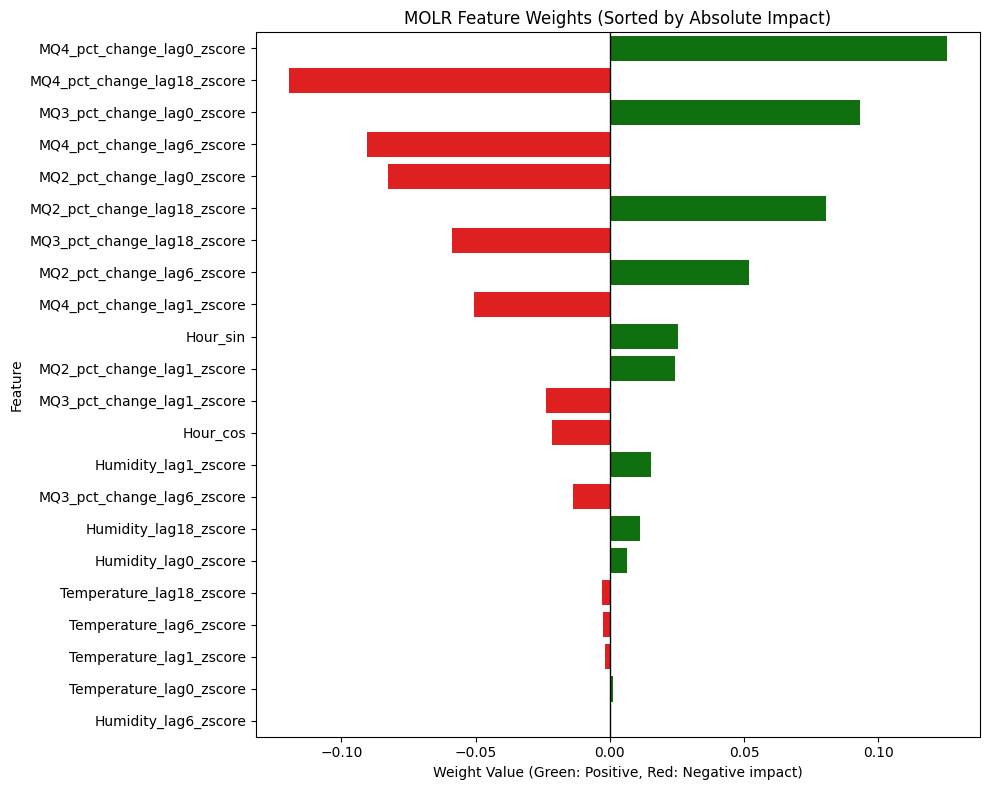

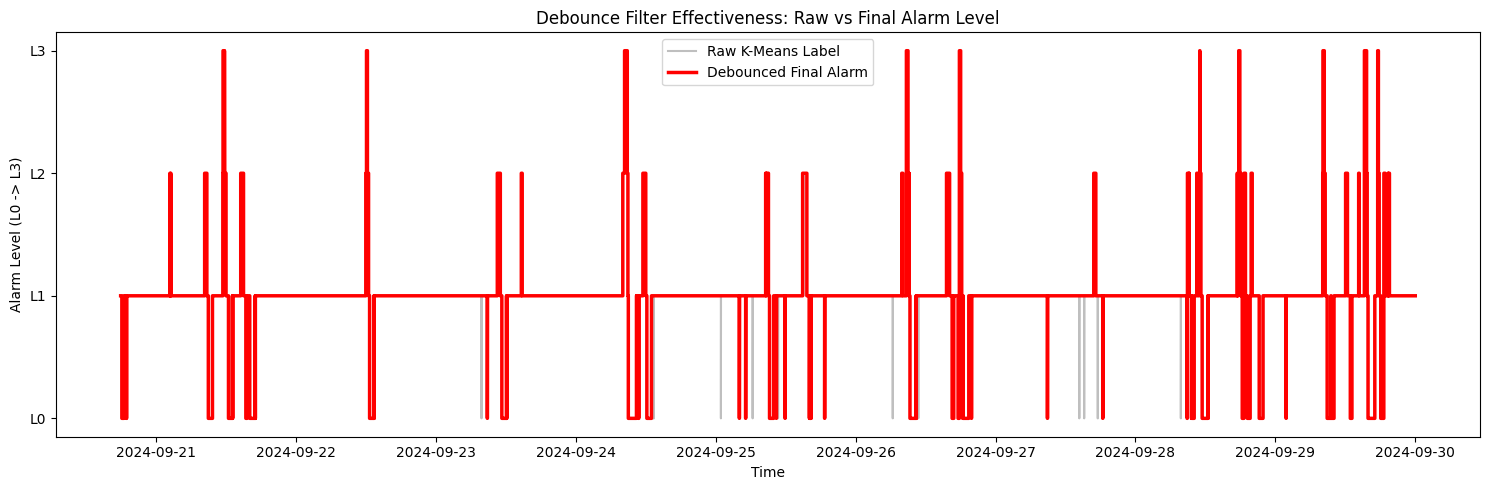

In [ ]:

#note(ctrl+/ để comment và uncomment đoạn code)

#preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# ĐỌC GOOGLE SHEET

# ===========================

#online
# sheet_id = "1kzYAxH2W3ia5sU__4ycZNgGVxvj1bSBiXHULtjBmhQo"

# url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

# raw = pd.read_csv(
#     url,
#     header=None,
#     low_memory=False
# )


#offline (nhớ chạy code upload file ở dưới trước)
file_path = "TD1_ESP32_SMELL_Part1.xlsx"
raw = pd.read_excel(
    file_path,
    header=None,
    dtype=str
)



header = raw.iloc[1]

df = raw.iloc[2:, :8].copy()

df.columns = header[:8]

df.columns = [
    "Date",
    "Time",
    "Status",
    "Temperature",
    "Humidity",
    "MQ2",
    "MQ3",
    "MQ4"
]
numeric_cols = [
    "Temperature",
    "Humidity",
    "MQ2",
    "MQ3",
    "MQ4"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.drop(
    columns=["Date", "Time"],
    inplace=True
)


#tạo bản copy dữ liệu thô
df_raw = df.copy(deep=True)
df = df_raw.copy()

#Median filter(lọc nhiễu)
sensor_cols = [
    "MQ2",
    "MQ3",
    "MQ4"
]
MEDIAN_WINDOW = 5
for sensor in sensor_cols:

    df[f"{sensor}_median"] = (
        df[sensor]
        .rolling(
            window=MEDIAN_WINDOW,
            center=False,
            min_periods=1
        )
        .median()
    )

#Moving average (làm trơn)
MA_WINDOW = 360
for sensor in sensor_cols:

    df[f"{sensor}_baseline"] = (
        df[f"{sensor}_median"]
        .rolling(
            window=MA_WINDOW,
            min_periods=1
        )
        .mean()
    )

#detrend (khử xu hướng vì k means không biết được xu hướng)
for sensor in sensor_cols:

    df[f"{sensor}_detrend"] = (
        df[f"{sensor}_median"]
        -
        df[f"{sensor}_baseline"]
    )

#Percent Change (% thay đổi so với mức nền của cảm biến đó)
EPS = 1e-8

for sensor in sensor_cols:

    df[f"{sensor}_pct_change"] = (
        df[f"{sensor}_detrend"]
        /
        (df[f"{sensor}_baseline"] + EPS)
    ) * 100


#check Nan
import numpy as np

print(
    np.isinf(
        df[
            [
                "MQ2_pct_change",
                "MQ3_pct_change",
                "MQ4_pct_change"
            ]
        ]
    ).sum()
)





from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
#kiểm tra số cluster tốt nhât(xem xem k=4 có thực hiện được không)
# ==========================
# Dữ liệu đầu vào
# ==========================

X = df[["MQ2_pct_change"]].values

k_range = range(2, 8)

inertias = []
silhouette_scores = []

for k in k_range:

    print(f"Running K = {k} ...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=3          # giảm để chạy nhanh hơn
    )

    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)

    score = silhouette_score(
        X,
        labels,
        sample_size=5000,     # chỉ lấy 5000 điểm để tính
        random_state=42
    )

    silhouette_scores.append(score)

    print(f"Done K = {k} | Silhouette = {score:.4f}")

# ==========================
# Elbow
# ==========================

plt.figure(figsize=(6,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# ==========================
# Silhouette
# ==========================

plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()

# ==========================
# Kết quả
# ==========================

print("\n===== RESULT =====")

for k, inertia, score in zip(k_range, inertias, silhouette_scores):
    print(
        f"K={k} | Inertia={inertia:.2f} | Silhouette={score:.4f}"
    )








#Chạy K-means với k=4 gán nhãn L0-L3
from sklearn.cluster import KMeans
import numpy as np

# ==========================
# KMeans trên MQ2_pct_change
# ==========================

X = df[["MQ2_pct_change"]].values

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

raw_labels = kmeans.fit_predict(X)

# ==========================
# Sắp xếp centroid tăng dần
# ==========================

centers = kmeans.cluster_centers_.flatten()

sorted_idx = np.argsort(centers)

# cluster gốc -> L0,L1,L2,L3
label_map = {
    old_cluster: new_level
    for new_level, old_cluster in enumerate(sorted_idx)
}

# Gán nhãn
df["pollution_level"] = [
    label_map[label]
    for label in raw_labels
]

# ==========================
# Kiểm tra centroid
# ==========================

print("\n========== Cluster Center ==========\n")

for new_level, old_cluster in enumerate(sorted_idx):

    print(
        f"L{new_level}"
        f" | centroid = {centers[old_cluster]:.3f}%"
        f" | samples = {(raw_labels == old_cluster).sum()}"
    )

# ==========================
# Thống kê số lượng từng mức
# ==========================

print("\n========== Pollution Level ==========\n")

print(
    df["pollution_level"]
    .value_counts()
    .sort_index()
)




# #phase 4: valid lại nhãn
# # ==========================
# # Phân bổ theo giờ
# # ==========================

# df["Hour"] = df["Timestamp"].dt.hour

# hour_distribution = df.pivot_table(
#     index="Hour",
#     columns="pollution_level",
#     values="MQ2_pct_change",
#     aggfunc="count",
#     fill_value=0
# )

# print("\n========== Distribution by Hour ==========\n")
# print(hour_distribution)
# #vẽ biểu đồ phân bổ theo giờ
# plt.figure(figsize=(14,6))

# hour_distribution.plot(
#     kind="bar",
#     stacked=True
# )

# plt.xlabel("Hour")
# plt.ylabel("Number of Samples")
# plt.title("Distribution of Pollution Levels by Hour")

# plt.grid(axis="y", alpha=0.3)

# plt.tight_layout()
# plt.show()


# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# plt.figure(figsize=(14, 6))

# # Đặt màu chuẩn cho 4 mức
# colors = {0: "blue", 1: "green", 2: "orange", 3: "red"}

# # Vẽ các điểm dữ liệu thực tế
# sns.scatterplot(
#     data=df,
#     x="Hour",
#     y="MQ2_pct_change",
#     hue="pollution_level",
#     palette=colors,
#     alpha=0.5,
#     s=15
# )

# # Kẻ 4 đường centroid với màu tương ứng và chú thích rõ ràng
# centroids = np.sort(centers)
# for i, c in enumerate(centroids):
#     plt.axhline(
#         y=c,
#         color=colors[i],
#         linestyle="--",
#         linewidth=1.5,
#         alpha=0.8,
#         label=f'Centroid L{i} ({c:.2f}%)'
#     )

# plt.xticks(range(24))
# plt.xlabel("Giờ trong ngày")
# plt.ylabel("MQ2 % Thay đổi (Thực tế)")
# plt.title("Phân bố % thay đổi thực tế và Nhãn K-Means theo giờ")

# plt.grid(True, alpha=0.3)
# plt.legend(title="Chú thích", loc='upper right', bbox_to_anchor=(1.15, 1))
# plt.tight_layout()
# plt.show()


# # ==========================
# # Xử lý spike ở nhiệt độ thấp (<30°C)
# # ==========================

# low_temp_spikes = df[
#     (df["Temperature"] < 30) &
#     (df["pollution_level"].isin([2, 3]))
# ]

# print("\n========== Low Temp Spikes (<30°C) ==========\n")
# print(f"Số lượng cảnh báo L2/L3 khi nhiệt độ thấp: {len(low_temp_spikes)}")

# if len(low_temp_spikes) > 0:
#     print("\nPhân bổ spike theo giờ:")
#     print(
#         low_temp_spikes["Hour"]
#         .value_counts()
#         .sort_index()
#     )



# ==========================================
# GIAI ĐOẠN 5: FEATURE ENGINEERING CHO MOLR (tạo đặc trưng theo thời gian)
# ==========================================
import numpy as np

# 1. Tạo Target xa hơn (Dự báo trước 5 bước thời gian)
TARGET_STEP = 5
df[f"target_t{TARGET_STEP}"] = df["MQ2_pct_change"].shift(-TARGET_STEP)

# 2. Tạo Lag features (Bao gồm hiện tại lag0 và quá khứ lag1, lag2, lag3) (lag là thời gian quá khứ)
base_features = [
    "MQ2_pct_change",
    "MQ3_pct_change",
    "MQ4_pct_change",
    "Temperature",
    "Humidity"
]

lag_cols = []
for col in base_features:
    # Giá trị hiện tại (không lag)
    df[f"{col}_lag0"] = df[col]
    lag_cols.append(f"{col}_lag0")

    # Giá trị quá khứ
    for lag in [1, 6, 18]:
        lag_name = f"{col}_lag{lag}"
        df[lag_name] = df[col].shift(lag)
        lag_cols.append(lag_name)

# Khai báo lại cột Hour (phòng trường hợp mất)
if "Hour" not in df.columns:
    df["Hour"] = df["Timestamp"].dt.hour

# 3. Tạo Feature giờ theo chu kỳ (Sin/Cos)
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

# 4. Running Z-score chuẩn hóa dữ liệu
Z_WINDOW = 360

for col in lag_cols:
    roll = df[col].rolling(window=Z_WINDOW, min_periods=1)
    run_mean = roll.mean()
    run_std = roll.std().replace(0, 1e-8)

    # Tạo cột zscore riêng
    df[f"{col}_zscore"] = (df[col] - run_mean) / run_std

# 5. Dọn dẹp dữ liệu (xóa các dòng NaN do lệnh shift)
df_molr = df.dropna().copy()

# ==========================
# Kiểm tra kết quả
# ==========================
print("\n========== Feature Engineering Data ==========\n")
print(f"Số lượng features đầu vào: {len(lag_cols) + 2} (bao gồm Hour_sin/cos)")
print(f"Target dự báo: target_t{TARGET_STEP}\n")

# In thử để kiểm tra
display_cols = [
    "MQ2_pct_change_lag0_zscore",
    "MQ2_pct_change_lag1_zscore",
    "Hour_sin",
    f"target_t{TARGET_STEP}"
]
print(df_molr[display_cols].head())






#(thuật toán này dự đoán y xong rồi dùng y đê quay lại tính các trọng số w,b(bản chất chỉ là phép nhân vector))
# ==========================================
# GIAI ĐOẠN 6: XÂY DỰNG MOLR (SGD + RIDGE) - TARGET t+5
# ==========================================
import numpy as np

# 1. Chuẩn bị tập X (features)
# lag_cols lúc này đã bao gồm cả lag0 (hiện tại) và lag1, 2, 3 (quá khứ)
feature_cols = [f"{col}_zscore" for col in lag_cols] + ["Hour_sin", "Hour_cos"]
X = df_molr[feature_cols].values

# 2. Xử lý Target (Dự đoán Delta giữa t+5 và t)
y_current = df_molr["MQ2_pct_change"].values  # Giá trị thực tế hiện tại
y_true_t5 = df_molr["target_t5"].values       # Target t+5
delta_y = y_true_t5 - y_current               # Khoảng chênh lệch (Delta) cần học

# 3. Đánh giá Baseline Persistence Model (ŷ(t+5) = x(t))
# Giả định 5 bước sau nồng độ không đổi
rmse_baseline = np.sqrt(np.mean((y_true_t5 - y_current)**2))

# 4. Khởi tạo tham số cho MOLR
learning_rate = 0.001
l2_lambda = 0.01
n_features = X.shape[1]

w = np.zeros(n_features)
b = 0.0

delta_pred_molr = np.zeros(len(delta_y))

# 5. Huấn luyện Online (SGD update từng mẫu)
for i in range(len(X)):
    x_i = X[i]
    d_i = delta_y[i]

    # Tính dự báo độ chênh lệch (Delta)
    d_hat = np.dot(w, x_i) + b
    delta_pred_molr[i] = d_hat

    # Tính sai số trên Delta
    error = d_hat - d_i

    # Cập nhật trọng số SGD
    w -= learning_rate * (error * x_i + l2_lambda * w)
    b -= learning_rate * error

# 6. Lấy kết quả Delta cộng trả lại vào y_current để ra dự báo gốc
y_pred_molr = y_current + delta_pred_molr
rmse_molr = np.sqrt(np.mean((y_true_t5 - y_pred_molr)**2))

# ==========================
# In kết quả so sánh
# ==========================
print("\n========== ĐÁNH GIÁ MÔ HÌNH MOLR (t+5) ==========\n")
print(f"RMSE của Baseline Persistence Model (t+5) : {rmse_baseline:.4f}")
print(f"RMSE của Mô hình MOLR (Online)            : {rmse_molr:.4f}")

improvement = ((rmse_baseline - rmse_molr) / rmse_baseline) * 100
print(f"-> MOLR cải thiện sai số được             : {improvement:.2f}%\n")




# ==========================================
# ĐÁNH GIÁ LẠI: BỎ QUA GIAI ĐOẠN KHỞI ĐỘNG (WARM-UP)
# ==========================================

# Lấy mốc 50% dữ liệu để chia đôi
split_idx = int(len(y_true_t5) * 0.5)

# Trích xuất dữ liệu nửa sau (khi mô hình đã hội tụ)
y_true_stable = y_true_t5[split_idx:]
y_pred_baseline_stable = y_current[split_idx:]
y_pred_molr_stable = y_pred_molr[split_idx:]

# Tính RMSE cho nửa sau
rmse_baseline_stable = np.sqrt(np.mean((y_true_stable - y_pred_baseline_stable)**2))
rmse_molr_stable = np.sqrt(np.mean((y_true_stable - y_pred_molr_stable)**2))

print("\n========== ĐÁNH GIÁ Ở GIAI ĐOẠN ỔN ĐỊNH (50% CUỐI) ==========\n")
print(f"RMSE Baseline (Đã hội tụ) : {rmse_baseline_stable:.4f}")
print(f"RMSE MOLR (Đã hội tụ)     : {rmse_molr_stable:.4f}")

improvement_stable = ((rmse_baseline_stable - rmse_molr_stable) / rmse_baseline_stable) * 100
print(f"-> MOLR thực tế cải thiện : {improvement_stable:.2f}%")

# ==========================================
# KIỂM TRA MULTICOLLINEARITY GIỮA CÁC LAG
# ==========================================
corr_matrix = df_molr[[
    "MQ2_pct_change_lag0_zscore",
    "MQ2_pct_change_lag1_zscore",
    "MQ2_pct_change_lag6_zscore",
    "MQ2_pct_change_lag18_zscore",
]].corr()
print("\n========== CORRELATION MATRIX (MQ2 lag0-3) ==========\n")
print(corr_matrix)

print("\nTrọng số (Weights) mô hình t+5:")
for name, weight in zip(feature_cols, w):
    print(f"- {name:<30}: {weight:.4f}")

# Loại bỏ khoảng thời gian có spike lớn ra khỏi tập đánh giá "ổn định", xem RMSE có còn thắng không
mask_no_spike = ~df_molr["Timestamp"].between("2024-09-23 14:00:00", "2024-09-23 16:00:00")
stable_no_spike = mask_no_spike.values[split_idx:]

rmse_baseline_clean = np.sqrt(np.mean((y_true_stable[stable_no_spike] - y_pred_baseline_stable[stable_no_spike])**2))
rmse_molr_clean = np.sqrt(np.mean((y_true_stable[stable_no_spike] - y_pred_molr_stable[stable_no_spike])**2))

print(f"RMSE Baseline (bỏ spike) : {rmse_baseline_clean:.4f}")
print(f"RMSE MOLR (bỏ spike)     : {rmse_molr_clean:.4f}")



# ==========================================
# GIAI ĐOẠN 7: HẬU XỬ LÝ (LỌC CHỐNG BÁO ĐỘNG GIẢ)
# ==========================================
import numpy as np

# Số nhịp đo liên tiếp cần thiết để xác nhận mức cảnh báo mới
# Nếu thiết bị đo 1 giây/lần -> Cần 3 giây giữ nguyên trạng thái mới bật/tắt còi
N_CONFIRM = 3

final_levels = []
# Lấy mức ô nhiễm đầu tiên làm trạng thái gốc
current_state = df["pollution_level"].iloc[0]
confirm_count = 0

# Duyệt qua từng nhịp đo (mô phỏng logic chạy trên vi điều khiển)
for raw_state in df["pollution_level"]:
    if raw_state == current_state:
        # Nếu trạng thái không đổi, reset bộ đếm nhiễu
        confirm_count = 0
    else:
        # Nếu có dấu hiệu nhảy mức ô nhiễm, tăng bộ đếm
        confirm_count += 1
        if confirm_count >= N_CONFIRM:
            # Nếu mức mới giữ vững đủ N_CONFIRM lần -> Chính thức đổi trạng thái
            current_state = raw_state
            confirm_count = 0

    final_levels.append(current_state)

# Ghi lại kết quả cảnh báo cuối cùng
df["Final_Alarm_Level"] = final_levels

# ==========================
# ĐÁNH GIÁ HIỆU QUẢ BỘ LỌC
# ==========================
print("\n========== KẾT QUẢ BỘ LỌC CHỐNG BÁO ĐỘNG GIẢ ==========\n")

# Đếm số lần hệ thống bị thay đổi trạng thái (bật/tắt hoặc nhảy mức)
raw_flips = (df["pollution_level"] != df["pollution_level"].shift()).sum()
final_flips = (df["Final_Alarm_Level"] != df["Final_Alarm_Level"].shift()).sum()

print(f"Số lần trạng thái nhảy mức (Chưa lọc) : {raw_flips} lần")
print(f"Số lần trạng thái nhảy mức (Đã lọc)   : {final_flips} lần")
print(f"-> Bộ lọc đã chặn được {raw_flips - final_flips} lần còi báo động chập chờn do nhiễu.\n")

# Tìm và in ra một đoạn dữ liệu thực tế có sự can thiệp của bộ lọc để đối chiếu
diff_mask = df["pollution_level"] != df["Final_Alarm_Level"]
if diff_mask.sum() > 0:
    print("Minh họa dữ liệu (Trước và Sau khi qua bộ lọc):")
    idx_example = df[diff_mask].index[0]
    start_idx = max(0, idx_example - 4)
    end_idx = min(len(df), idx_example + 5)
    print(df[["Timestamp", "MQ2_pct_change", "pollution_level", "Final_Alarm_Level"]].loc[start_idx:end_idx])
else:
    print("Không phát hiện tình trạng chập chờn trong tập dữ liệu hiện tại.")




import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd


# ==========================================
# GIAI ĐOẠN 8: VẼ 6 BIỂU ĐỒ BẢO VỆ PIPELINE
# ==========================================

# Lọc lấy dữ liệu của 7 ngày đầu tiên để biểu đồ thoáng và giống yêu cầu
start_time = df["Timestamp"].min()
df_plot = df[df["Timestamp"] < (start_time + pd.Timedelta(days=7))]

# 1. Biểu đồ Time Series Pipeline đại diện (Raw -> Median -> MA)
fig, ax = plt.subplots(figsize=(15, 6))
fig.suptitle('Signal Processing Pipeline: Lọc nhiễu và trích xuất Baseline nền (7 ngày)', fontsize=16)

# Đặt định dạng thời gian giống hệt ảnh: %b (Tháng chữ viết tắt) %d (Ngày)
date_format = mdates.DateFormatter('%b %d')

# Dùng MQ2 làm đại diện
sensor = 'MQ2'

# Vẽ bằng df_plot (dữ liệu đã lọc 7 ngày)
# 1. Dữ liệu thô (Vàng cam)
ax.plot(df_plot["Timestamp"], df_plot[sensor], label='1. Raw Sensor Data', color='goldenrod', alpha=0.6, linewidth=1.2)

# 2. Sau khi qua Median Filter (Xanh dương)
ax.plot(df_plot["Timestamp"], df_plot[f'{sensor}_median'], label='2. After Median Filter (Khử nhiễu gai)', color='blue', linewidth=1.5, alpha=0.8)

# 3. Sau khi qua cả Median + MA (Đỏ)
ax.plot(df_plot["Timestamp"], df_plot[f'{sensor}_baseline'], label='3. Baseline (Đường nền chuẩn hóa)', color='red', linestyle='-', linewidth=2.5)

ax.set_ylabel('Sensor Value (ADC)')
ax.legend(loc='upper right', fontsize=11)

# Áp dụng định dạng trục X theo yêu cầu
ax.xaxis.set_major_formatter(date_format)
# Ép hiển thị mốc thời gian nhảy theo từng ngày (DayLocator) để nhìn giống ảnh
ax.xaxis.set_major_locator(mdates.DayLocator())

plt.xlabel('Thời gian đo', fontsize=12)
# Có thể để góc xoay = 0 (nằm ngang) nếu ít mốc ngày, hoặc giữ 45 nếu chữ bị sát nhau
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Biểu đồ Elbow + Silhouette
# LƯU Ý: Để chạy được phần này, bạn PHẢI bỏ comment (uncomment) đoạn code chạy vòng lặp k_range ở dòng 133-175
try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Subplot 1: Elbow
    ax1.plot(k_range, inertias, marker='o', linestyle='-', color='b')
    ax1.set_title('Elbow Method (Inertia)')
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia')
    ax1.axvline(x=4, color='r', linestyle='--', label='k=4 (Chosen)')
    ax1.legend()

    # Subplot 2: Silhouette
    ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
    ax2.set_title('Silhouette Score')
    ax2.set_xlabel('Number of clusters (k)')
    ax2.set_ylabel('Score')
    ax2.axvline(x=4, color='r', linestyle='--', label='k=4 (Chosen)')
    ax2.legend()

    plt.tight_layout()
    plt.show()
except NameError:
    print("Bỏ qua biểu đồ 2: Bạn chưa uncomment đoạn code tính Elbow & Silhouette phía trên.")


# 3. Scatter Hour vs pct_change theo cluster
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Hour', y='MQ2_pct_change', hue='pollution_level', palette='tab10', alpha=0.6)

# Vẽ các đường ngang tương ứng với các Centroid
for i, c in enumerate(np.sort(centers)):
    plt.axhline(y=c, color='black', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Centroid L{i}' if i==0 else "")

plt.title('Cluster Distribution: Hour of Day vs MQ2 Pct_Change')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('MQ2 Percentage Change from Baseline (%)')
# Lọc trùng lặp nhãn legend do axhline
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 4. Actual vs MOLR-predicted vs Baseline
plt.figure(figsize=(15, 6))

# Lấy trục thời gian tương ứng với df_molr (từ đoạn 50% cuối)
split_idx = int(len(y_true_t5) * 0.5)
time_x = df_molr["Timestamp"].iloc[split_idx:]

plt.plot(time_x, y_true_t5[split_idx:], label='Actual Target (t+5)', color='black', alpha=0.8)
plt.plot(time_x, y_pred_molr[split_idx:], label='MOLR Predicted', color='blue', alpha=0.9)
plt.plot(time_x, y_current[split_idx:], label='Baseline (Persistence)', color='red', linestyle=':', alpha=0.7)

plt.title('Model Prediction on Stable Data (Second Half)')
plt.xlabel('Time')
plt.ylabel('MQ2 Pct Change')
plt.legend()
plt.tight_layout()
plt.show()




# ==========================================
# CHÈN THÊM: BIỂU ĐỒ PACF (BẢO VỆ FEATURE LAG)
# ==========================================
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Dùng dữ liệu trước khi train model (df_molr) để phân tích
plt.figure(figsize=(12, 5))
plot_pacf(df_molr["MQ2_pct_change"].dropna(), lags=20, method='ywm',
          title="Partial Autocorrelation Function (PACF) của MQ2 Pct Change",
          ax=plt.gca())

plt.xlabel("Độ trễ (Lags - Số nhịp thời gian trong quá khứ)")
plt.ylabel("Hệ số tương quan (Thống kê)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# 5. Bar chart trọng số w
# Lấy weights (w) và feature_cols từ Giai đoạn 6
df_weights = pd.DataFrame({'feature': feature_cols, 'weight': w})
df_weights['abs_weight'] = df_weights['weight'].abs()
df_weights_sorted = df_weights.sort_values(by='abs_weight', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['green' if val > 0 else 'red' for val in df_weights_sorted['weight']]

sns.barplot(x='weight', y='feature', data=df_weights_sorted, palette=colors)
plt.title('MOLR Feature Weights (Sorted by Absolute Impact)')
plt.xlabel('Weight Value (Green: Positive, Red: Negative impact)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


# 6. Step plot pollution_level thô vs Final_Alarm_Level
plt.figure(figsize=(15, 5))

# Thay đổi tên cột cho đúng với dataframe hiện tại
plt.step(df["Timestamp"], df['pollution_level'], label='Raw K-Means Label',
         color='gray', alpha=0.5, where='post')
plt.step(df["Timestamp"], df['Final_Alarm_Level'], label='Debounced Final Alarm',
         color='red', linewidth=2.5, where='post')

plt.title('Debounce Filter Effectiveness: Raw vs Final Alarm Level')
plt.xlabel('Time')
plt.ylabel('Alarm Level (L0 -> L3)')
plt.yticks([0, 1, 2, 3], ['L0', 'L1', 'L2', 'L3'])
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#train offline
from google.colab import files

uploaded = files.upload()

Saving TD1_ESP32_SMELL_Part1.xlsx to TD1_ESP32_SMELL_Part1.xlsx
